### Kullanılan Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import joblib
import os


### Veri Setinin Yüklenmesi ve Analizi

In [2]:
CATEGORIES = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

DATA_DIR = "backend/data"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv", header=0, names=['label', 'title', 'description'])
test_df = pd.read_csv(f"{DATA_DIR}/test.csv", header=0, names=['label', 'title', 'description'])

print(f"Training set size: {len(train_df):,}")
print(f"Test set size: {len(test_df):,}")
print(f"\nFirst 5 rows of the dataset:")
train_df.head()

Training set size: 120,000
Test set size: 7,600

First 5 rows of the dataset:


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [3]:
print("Dataset info:")
print(train_df.info())
print("\nMissing value check:")
print(train_df.isnull().sum())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
None

Missing value check:
label          0
title          0
description    0
dtype: int64


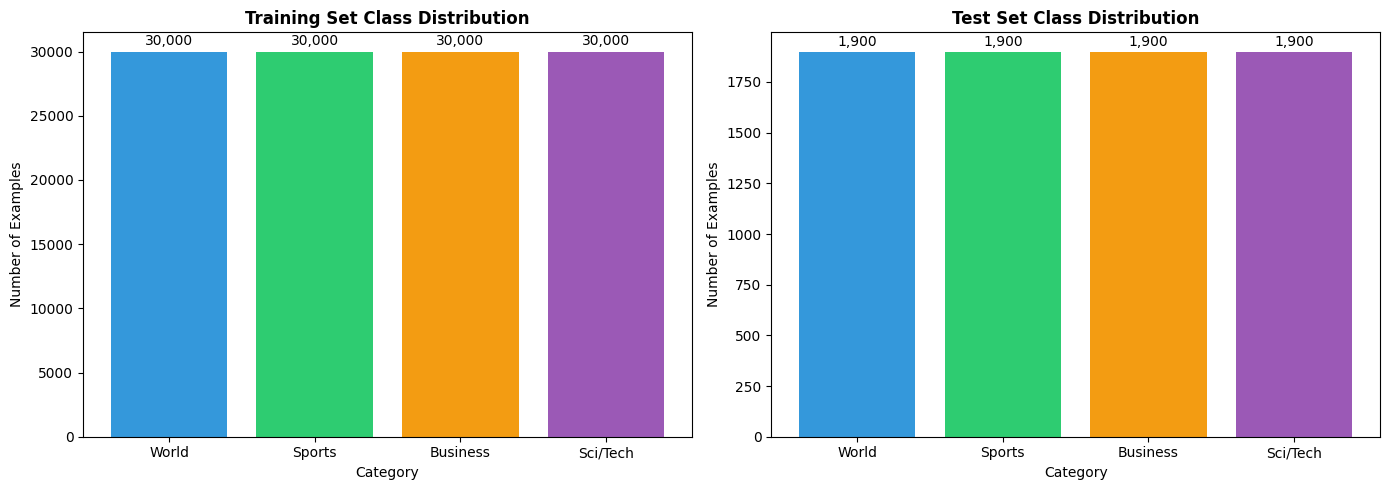

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_counts = train_df['label'].value_counts().sort_index()
colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars1 = axes[0].bar([CATEGORIES[i] for i in train_counts.index], train_counts.values, color=colors)
axes[0].set_title('Training Set Class Distribution', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Examples')
for bar, val in zip(bars1, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,}', ha='center')

# Test set
test_counts = test_df['label'].value_counts().sort_index()
bars2 = axes[1].bar([CATEGORIES[i] for i in test_counts.index], test_counts.values, color=colors)
axes[1].set_title('Test Set Class Distribution', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Examples')
for bar, val in zip(bars2, test_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:,}', ha='center')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

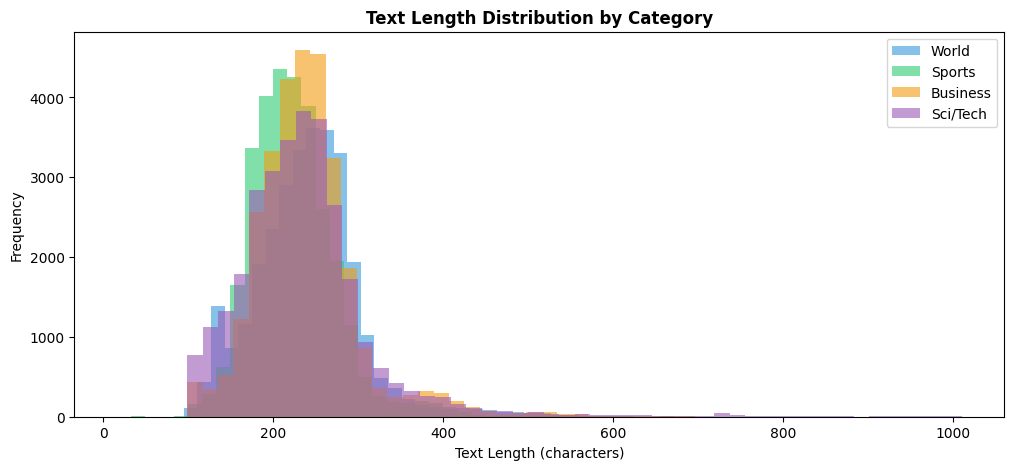


Average Text Length by Category
World: 241.6 characters
Sports: 223.6 characters
Business: 240.4 characters
Sci/Tech: 236.2 characters


In [5]:
# Text length analysis
train_df['text_length'] = train_df['title'].str.len() + train_df['description'].str.len()

fig, ax = plt.subplots(figsize=(12, 5))

for i, (label, color) in enumerate(zip(CATEGORIES.keys(), colors)):
    subset = train_df[train_df['label'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, label=CATEGORIES[label], color=color)

ax.set_title('Text Length Distribution by Category', fontweight='bold')
ax.set_xlabel('Text Length (characters)')
ax.set_ylabel('Frequency')
ax.legend()
plt.savefig('figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAverage Text Length by Category")
print("="*50)
for label in CATEGORIES.keys():
    avg_len = train_df[train_df['label'] == label]['text_length'].mean()
    print(f"{CATEGORIES[label]}: {avg_len:.1f} characters")

### Text Preprocessing

In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) 
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) 
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

def remove_stopwords(text):
    if not text:
        return ""
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

def preprocess_text(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    return text

sample_text = "Stock Market HITS Record High! The S&P 500 rose 2.5% today..."
print("Original text:")
print(f"  '{sample_text}'")
print("\nPreprocessed text:")
print(f"  '{preprocess_text(sample_text)}'")

Original text:
  'Stock Market HITS Record High! The S&P 500 rose 2.5% today...'

Preprocessed text:
  'stock market hits record high p rose today'


In [7]:
def combine_text(row):
    title = str(row['title']) if pd.notna(row['title']) else ""
    desc = str(row['description']) if pd.notna(row['description']) else ""
    return f"{title} {desc}".strip()

train_df['text'] = train_df.apply(combine_text, axis=1)
test_df['text'] = test_df.apply(combine_text, axis=1)

train_df['processed_text'] = train_df['text'].apply(preprocess_text)
test_df['processed_text'] = test_df['text'].apply(preprocess_text)

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 120000
Test set size: 7600


### TF-IDF Feature Extraction

In [8]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train = vectorizer.fit_transform(train_df['processed_text'])
X_test = vectorizer.transform(test_df['processed_text'])

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\nTF-IDF Vector Features")
print(f"Total feature count: {X_train.shape[1]:,}")
print(f"Training matrix size: {X_train.shape}")
print(f"Test matrix size: {X_test.shape}")
print(f"Sparsity ratio: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")


TF-IDF Vector Features
Total feature count: 10,000
Training matrix size: (120000, 10000)
Test matrix size: (7600, 10000)
Sparsity ratio: 99.78%


In [9]:
feature_names = vectorizer.get_feature_names_out()
print("\n Feature names:")
print(feature_names[:20])


 Feature names:
['aa' 'aapl' 'aaron' 'abandon' 'abandoned' 'abbas' 'abbey'
 'abbey national' 'abc' 'abducted' 'abdullah' 'abidjan' 'ability' 'able'
 'aboard' 'abroad' 'abruptly' 'absence' 'abu' 'abu ghraib']


### Selected Algoritms

In [10]:
models = {
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM': LinearSVC(C=1.0, max_iter=10000, random_state=42)
}

print("Model Hyperparameters:")
print("\nNaive Bayes:")
print("- alpha=1.0 (Laplace smoothing)")
print("\nLogistic Regression:")
print("- max_iter=1000")
print("- C=1.0 (inverse regularization strength)")
print("- solver='lbfgs' (default)")
print("\nSVM (LinearSVC):")
print("- C=1.0 (regularization parameter)")
print("- max_iter=10000")

Model Hyperparameters:

Naive Bayes:
- alpha=1.0 (Laplace smoothing)

Logistic Regression:
- max_iter=1000
- C=1.0 (inverse regularization strength)
- solver='lbfgs' (default)

SVM (LinearSVC):
- C=1.0 (regularization parameter)
- max_iter=10000


In [11]:
results = {}

for name, model in models.items():
    print(f"\n{name} training...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    print(f"--Accuracy:  {accuracy:.4f}")
    print(f"--Precision: {precision:.4f}")
    print(f"--Recall:    {recall:.4f}")
    print(f"--F1-Score:  {f1:.4f}")


Naive Bayes training...
--Accuracy:  0.8966
--Precision: 0.8962
--Recall:    0.8966
--F1-Score:  0.8962

Logistic Regression training...
--Accuracy:  0.9155
--Precision: 0.9153
--Recall:    0.9155
--F1-Score:  0.9153

SVM training...
--Accuracy:  0.9151
--Precision: 0.9150
--Recall:    0.9151
--F1-Score:  0.9150


In [12]:
print("\nModel Comparison Results")
print(f"\n{'Model':<25} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}\n")
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']:>12.4f} {res['precision']:>12.4f} {res['recall']:>12.4f} {res['f1']:>12.4f}")

best_model_name = max(results.keys(), key=lambda x: results[x]['f1'])
print(f"\nBest Model: {best_model_name} (F1-Score: {results[best_model_name]['f1']:.4f})")


Model Comparison Results

Model                         Accuracy    Precision       Recall     F1-Score

Naive Bayes                     0.8966       0.8962       0.8966       0.8962
Logistic Regression             0.9155       0.9153       0.9155       0.9153
SVM                             0.9151       0.9150       0.9151       0.9150

Best Model: Logistic Regression (F1-Score: 0.9153)


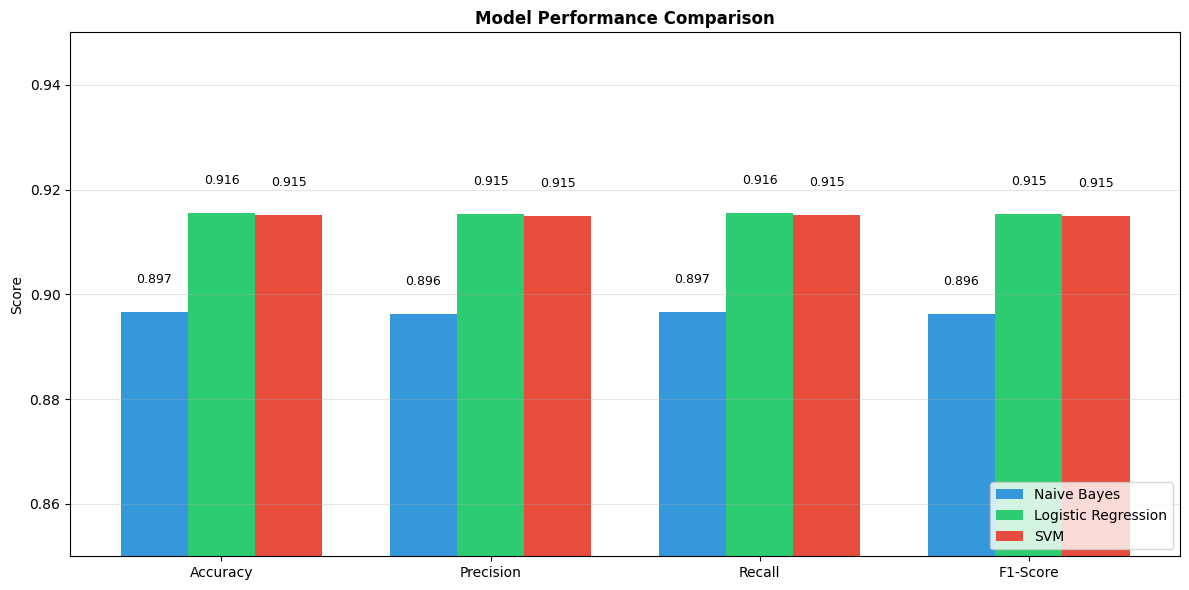

In [13]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = list(results.keys())

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(model_names, ['#3498db', '#2ecc71', '#e74c3c'])):
    values = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, values, width, label=name, color=color)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.legend(loc='lower right')
ax.set_ylim(0.85, 0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

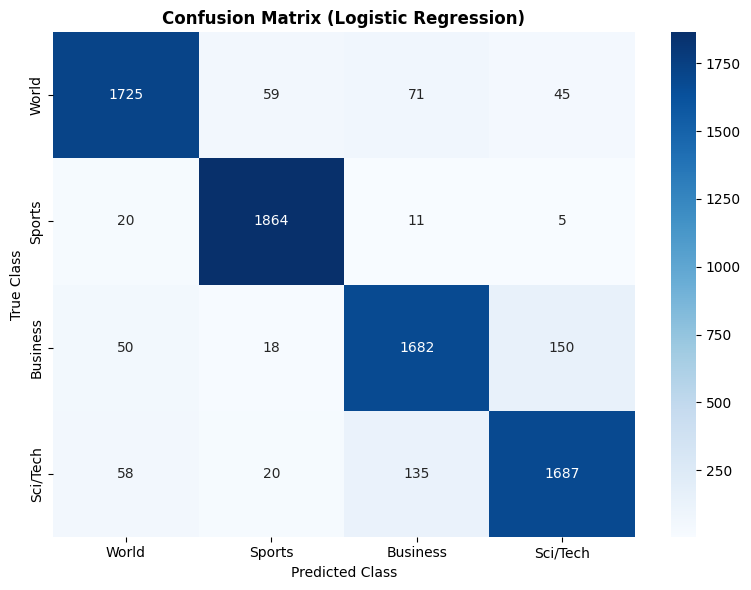

In [14]:
best_pred = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CATEGORIES[i] for i in sorted(CATEGORIES.keys())],
            yticklabels=[CATEGORIES[i] for i in sorted(CATEGORIES.keys())],
            ax=ax)
ax.set_title(f'Confusion Matrix ({best_model_name})', fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')

plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print(f"\nDetailed Classification Report ({best_model_name})\n")
labels = sorted(CATEGORIES.keys())
target_names = [CATEGORIES[i] for i in labels]
print(classification_report(y_test, best_pred, labels=labels, target_names=target_names))


Detailed Classification Report (Logistic Regression)

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



### Save best model

In [16]:
os.makedirs('backend/models', exist_ok=True)

best_model = results[best_model_name]['model']
joblib.dump(best_model, 'backend/models/best_model.pkl')
joblib.dump(vectorizer, 'backend/models/vectorizer.pkl')
joblib.dump({'model_name': best_model_name, 'categories': CATEGORIES}, 'backend/models/metadata.pkl')

['backend/models/metadata.pkl']

### Examples

In [17]:
test_articles = [
    {"title": "Stock Market Hits Record High", "desc": "Wall Street sees major gains today"},
    {"title": "NASA Discovers New Planet", "desc": "Scientists find potentially habitable exoplanet"},
    {"title": "World Cup Final Results", "desc": "Argentina wins championship against France"},
    {"title": "UN Climate Summit", "desc": "World leaders discuss environmental policies"}
]

print("\nExample Predictions:\n")

for article in test_articles:
    text = f"{article['title']} {article['desc']}"
    processed = preprocess_text(text)
    vec = vectorizer.transform([processed])
    pred = best_model.predict(vec)[0]
    
    print(f"\n{article['title']}")
    print(f"---Prediction: {CATEGORIES[pred]}")


Example Predictions:


Stock Market Hits Record High
---Prediction: Business

NASA Discovers New Planet
---Prediction: Sci/Tech

World Cup Final Results
---Prediction: Sports

UN Climate Summit
---Prediction: World
